# S4_Sustained_Output_Onset_JDSSS.ipynb
This notebook compares signals of sustained output onset for SnowModel and Sentinel methods with observations at the JDSSS site.

For additional details see ../paper_new/fig_2_CUES_SM_S1_QC_YR_ALL_DATA.ipynb  


In [54]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import importlib
import sys
from pathlib import Path
import xarray as xr
import pandas as pd


# gets rid of a lot of annoying warnings, we know there are NaNs (might want to remove this to double check)
import warnings
warnings.filterwarnings("ignore")


In [55]:
sys.path.insert(1, '../scripts/')

In [56]:
import metadata as metadata
import load_data as load_data
import plotting as plotting
import melt_phases as melt_phases
import fig_2b as fig_2b


In [57]:
import importlib
importlib.reload(metadata)
importlib.reload(load_data)
importlib.reload(plotting)
importlib.reload(melt_phases)
importlib.reload(fig_2b)


<module 'fig_2b' from '/glade/u/home/rossamower/school/uw/cues_git/cues_sentinel_snowmodel/python/supporting_information/../scripts/fig_2b.py'>

# Load Data

## Metadata

### point locations

#### CUES

In [58]:
importlib.reload(metadata)
# load config
cues_cfg = metadata.load_yaml(Path(f"../../configs/CUES.yaml"))
# load point geometry
_,_,cues_x,cues_y,_ = metadata.get_point_geography(cues_cfg,'cues')
# load snowmodel filepath
sm_cues_OBS_swe_fpath = metadata.get_cuesOBS_fpath(cues_cfg,'swe')
sm_cues_OBS_sweMelt_fpath = metadata.get_cuesOBS_fpath(cues_cfg,'swe_melt')


### polygon geometries

In [59]:
importlib.reload(metadata)
# cues
cues_geog_fpath,aso_crs = metadata.get_shapefile_fpath(cues_cfg,"shapefile_fpath","zoom_2")
# ASO
aso_cfg = metadata.load_yaml(Path(f"../../configs/ASO.yaml"))
uscasj_geog_fpath,aso_crs = metadata.get_shapefile_fpath(aso_cfg,"basin_shapefile","USCASJ")
# read shapefile
## cues
cues_geog_gdf = gpd.read_file(cues_geog_fpath)
cues_proj_gdf = cues_geog_gdf.to_crs(f'EPSG:{aso_crs}')


## time series

### SWE

#### SnowModel

In [60]:
importlib.reload(load_data)
# SnowModel directory paths.
sm_cues_optimized_fpath = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/optimized/'
sm_cues_biased_fpath = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/biased/'
sm_cues_corrected_fpath = '/glade/u/home/rossamower/rmower/pixel/snowmodel/cues/outputs/wo_assim/conus_404/corrected/'


#### CUES

In [61]:
importlib.reload(load_data)
cues_obs_swe_qa_df,cues_obs_swe_NO_qa_df = load_data.load_cues_OBS_SWE(sm_cues_OBS_swe_fpath)
cues_obs_swe_all_df = pd.concat([cues_obs_swe_qa_df,cues_obs_swe_NO_qa_df])
cues_obs_swe_all_df.drop(columns = ['water_year'],inplace = True)
cues_obs_swe_all_df['DateTime'] = pd.to_datetime(cues_obs_swe_all_df['DateTime'])
cues_obs_swe_all_df.rename(columns = {'DateTime':'time',
                                      'SWE':'swed'},inplace = True)
cues_swe_ds = cues_obs_swe_all_df.set_index('time').to_xarray()
cues_swe_m_ds = (cues_swe_ds['swed'] / 1000).to_dataset(name = 'swed')


## Point Data

### SWE-Melt

In [62]:
importlib.reload(load_data)
df_lys = load_data.load_cues_OBS_SWE_melt(sm_cues_OBS_sweMelt_fpath)

### TAIR

In [63]:
ds_temp = xr.open_dataset('../../data/cues/cues/cues_2015_2025.nc')[['air_temperature','air_temperature_data_flag']]
ds_temp_day = ds_temp.resample(datetime='1D').mean()

### S-1 Backscatter

In [64]:
importlib.reload(load_data)
sentinel_cues_100m_2017 = load_data.load_sentinel_backscatter('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2017/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

sentinel_cues_100m_2018 = load_data.load_sentinel_backscatter('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2018/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

sentinel_cues_100m_2019 = load_data.load_sentinel_backscatter('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2019/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

sentinel_cues_100m_2020 = load_data.load_sentinel_backscatter('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2020/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

idy_cues,idx_cues = load_data.sm_intersect_rectilinear(sentinel_cues_100m_2017.y.values,sentinel_cues_100m_2017.x.values,cues_y,cues_x)

### S-1 Reference Scene

In [65]:
importlib.reload(load_data)                                                                   
sentinel_cues_reference_2017 = load_data.load_sentinel_reference('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2017/melt_thresh/reference/',
                                                                   aso_crs,
                                                                  cues_proj_gdf,
                                                                  )


sentinel_cues_reference_2018 = load_data.load_sentinel_reference('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2018/melt_thresh/reference/',
                                                                   aso_crs,
                                                                   cues_proj_gdf,
                  )

sentinel_cues_reference_2019 = load_data.load_sentinel_reference('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2019/melt_thresh/reference/',
                                                                   aso_crs,
                                                                  cues_proj_gdf,
                  )

sentinel_cues_reference_2020 = load_data.load_sentinel_reference('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2020/melt_thresh/reference/',
                                                                   aso_crs,
                                                                   cues_proj_gdf,
                  )

### SnowModel

#### SM-baseline

In [66]:
importlib.reload(load_data)

water_year = 2017
sm_point_biased_ds_2017 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_biased_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2018
sm_point_biased_ds_2018 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_biased_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2019
sm_point_biased_ds_2019 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_biased_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2020
sm_point_biased_ds_2020 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_biased_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)

#### SM-prec

In [67]:
importlib.reload(load_data)

water_year = 2017
sm_point_corrected_ds_2017 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_corrected_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2018
sm_point_corrected_ds_2018 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_corrected_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2019
sm_point_corrected_ds_2019 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_corrected_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2020
sm_point_corrected_ds_2020 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_corrected_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)

#### SM-optimized

In [68]:
importlib.reload(load_data)

water_year = 2017
sm_point_optimized_ds_2017 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_optimized_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2018
sm_point_optimized_ds_2018 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_optimized_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2019
sm_point_optimized_ds_2019 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_optimized_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)
water_year = 2020
sm_point_optimized_ds_2020 = load_data.load_point_snowmodel_liq_temp_swe_roff(water_year,
                                                                    sm_cues_optimized_fpath,
                                                                    idy_ = 0,
                                                                    idx_ = 0)

## Melt Phases

### SnowModel

In [69]:
importlib.reload(melt_phases)
# parameters.
water_thresh_surface_ = 0.0035
water_thresh_internal_ = 0.0001
min_runoff_rate_ = 0.001  # 1 mm cumulative runoff in forward window
output_merge_dry_hours_ = 48
ripen_gap_days_ = 7

#### SM-baseline

In [70]:
ph_rv_biased_2017 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_biased_ds_2017, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_biased_2018 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_biased_ds_2018, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_biased_2019 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_biased_ds_2019, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_biased_2020 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_biased_ds_2020, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)

#### SM-prec

In [71]:
ph_rv_prec_ADJ_2017 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_corrected_ds_2017, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_prec_ADJ_2018 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_corrected_ds_2018, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_prec_ADJ_2019 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_corrected_ds_2019, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_prec_ADJ_2020 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_corrected_ds_2020, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)

#### SM-optimized

In [72]:
ph_rv_optimized_2017 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_optimized_ds_2017, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_optimized_2018 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_optimized_ds_2018, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_optimized_2019 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_optimized_ds_2019, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)
ph_rv_optimized_2020 = melt_phases.classify_snowmodel_melt_phases_3h_full_revamp(
    sm_point_optimized_ds_2020, water_thresh_surface=water_thresh_surface_,
    water_thresh_internal=water_thresh_internal_, min_runoff_rate=min_runoff_rate_,
    output_merge_dry_hours=output_merge_dry_hours_, ripen_gap_days=ripen_gap_days_)

### Combined SnowModel

In [73]:
# Revamp data lists (same structure as original for comparison)
phase_rv_data_2017 = [ph_rv_biased_2017, ph_rv_prec_ADJ_2017, ph_rv_optimized_2017]
phase_rv_data_2018 = [ph_rv_biased_2018, ph_rv_prec_ADJ_2018, ph_rv_optimized_2018]
phase_rv_data_2019 = [ph_rv_biased_2019, ph_rv_prec_ADJ_2019, ph_rv_optimized_2019]
phase_rv_data_2020 = [ph_rv_biased_2020, ph_rv_prec_ADJ_2020, ph_rv_optimized_2020]

swe_mod_data_2017 = [sm_point_biased_ds_2017, sm_point_corrected_ds_2017, sm_point_optimized_ds_2017]
swe_mod_data_2018 = [sm_point_biased_ds_2018, sm_point_corrected_ds_2018, sm_point_optimized_ds_2018]
swe_mod_data_2019 = [sm_point_biased_ds_2019, sm_point_corrected_ds_2019, sm_point_optimized_ds_2019]
swe_mod_data_2020 = [sm_point_biased_ds_2020, sm_point_corrected_ds_2020, sm_point_optimized_ds_2020]

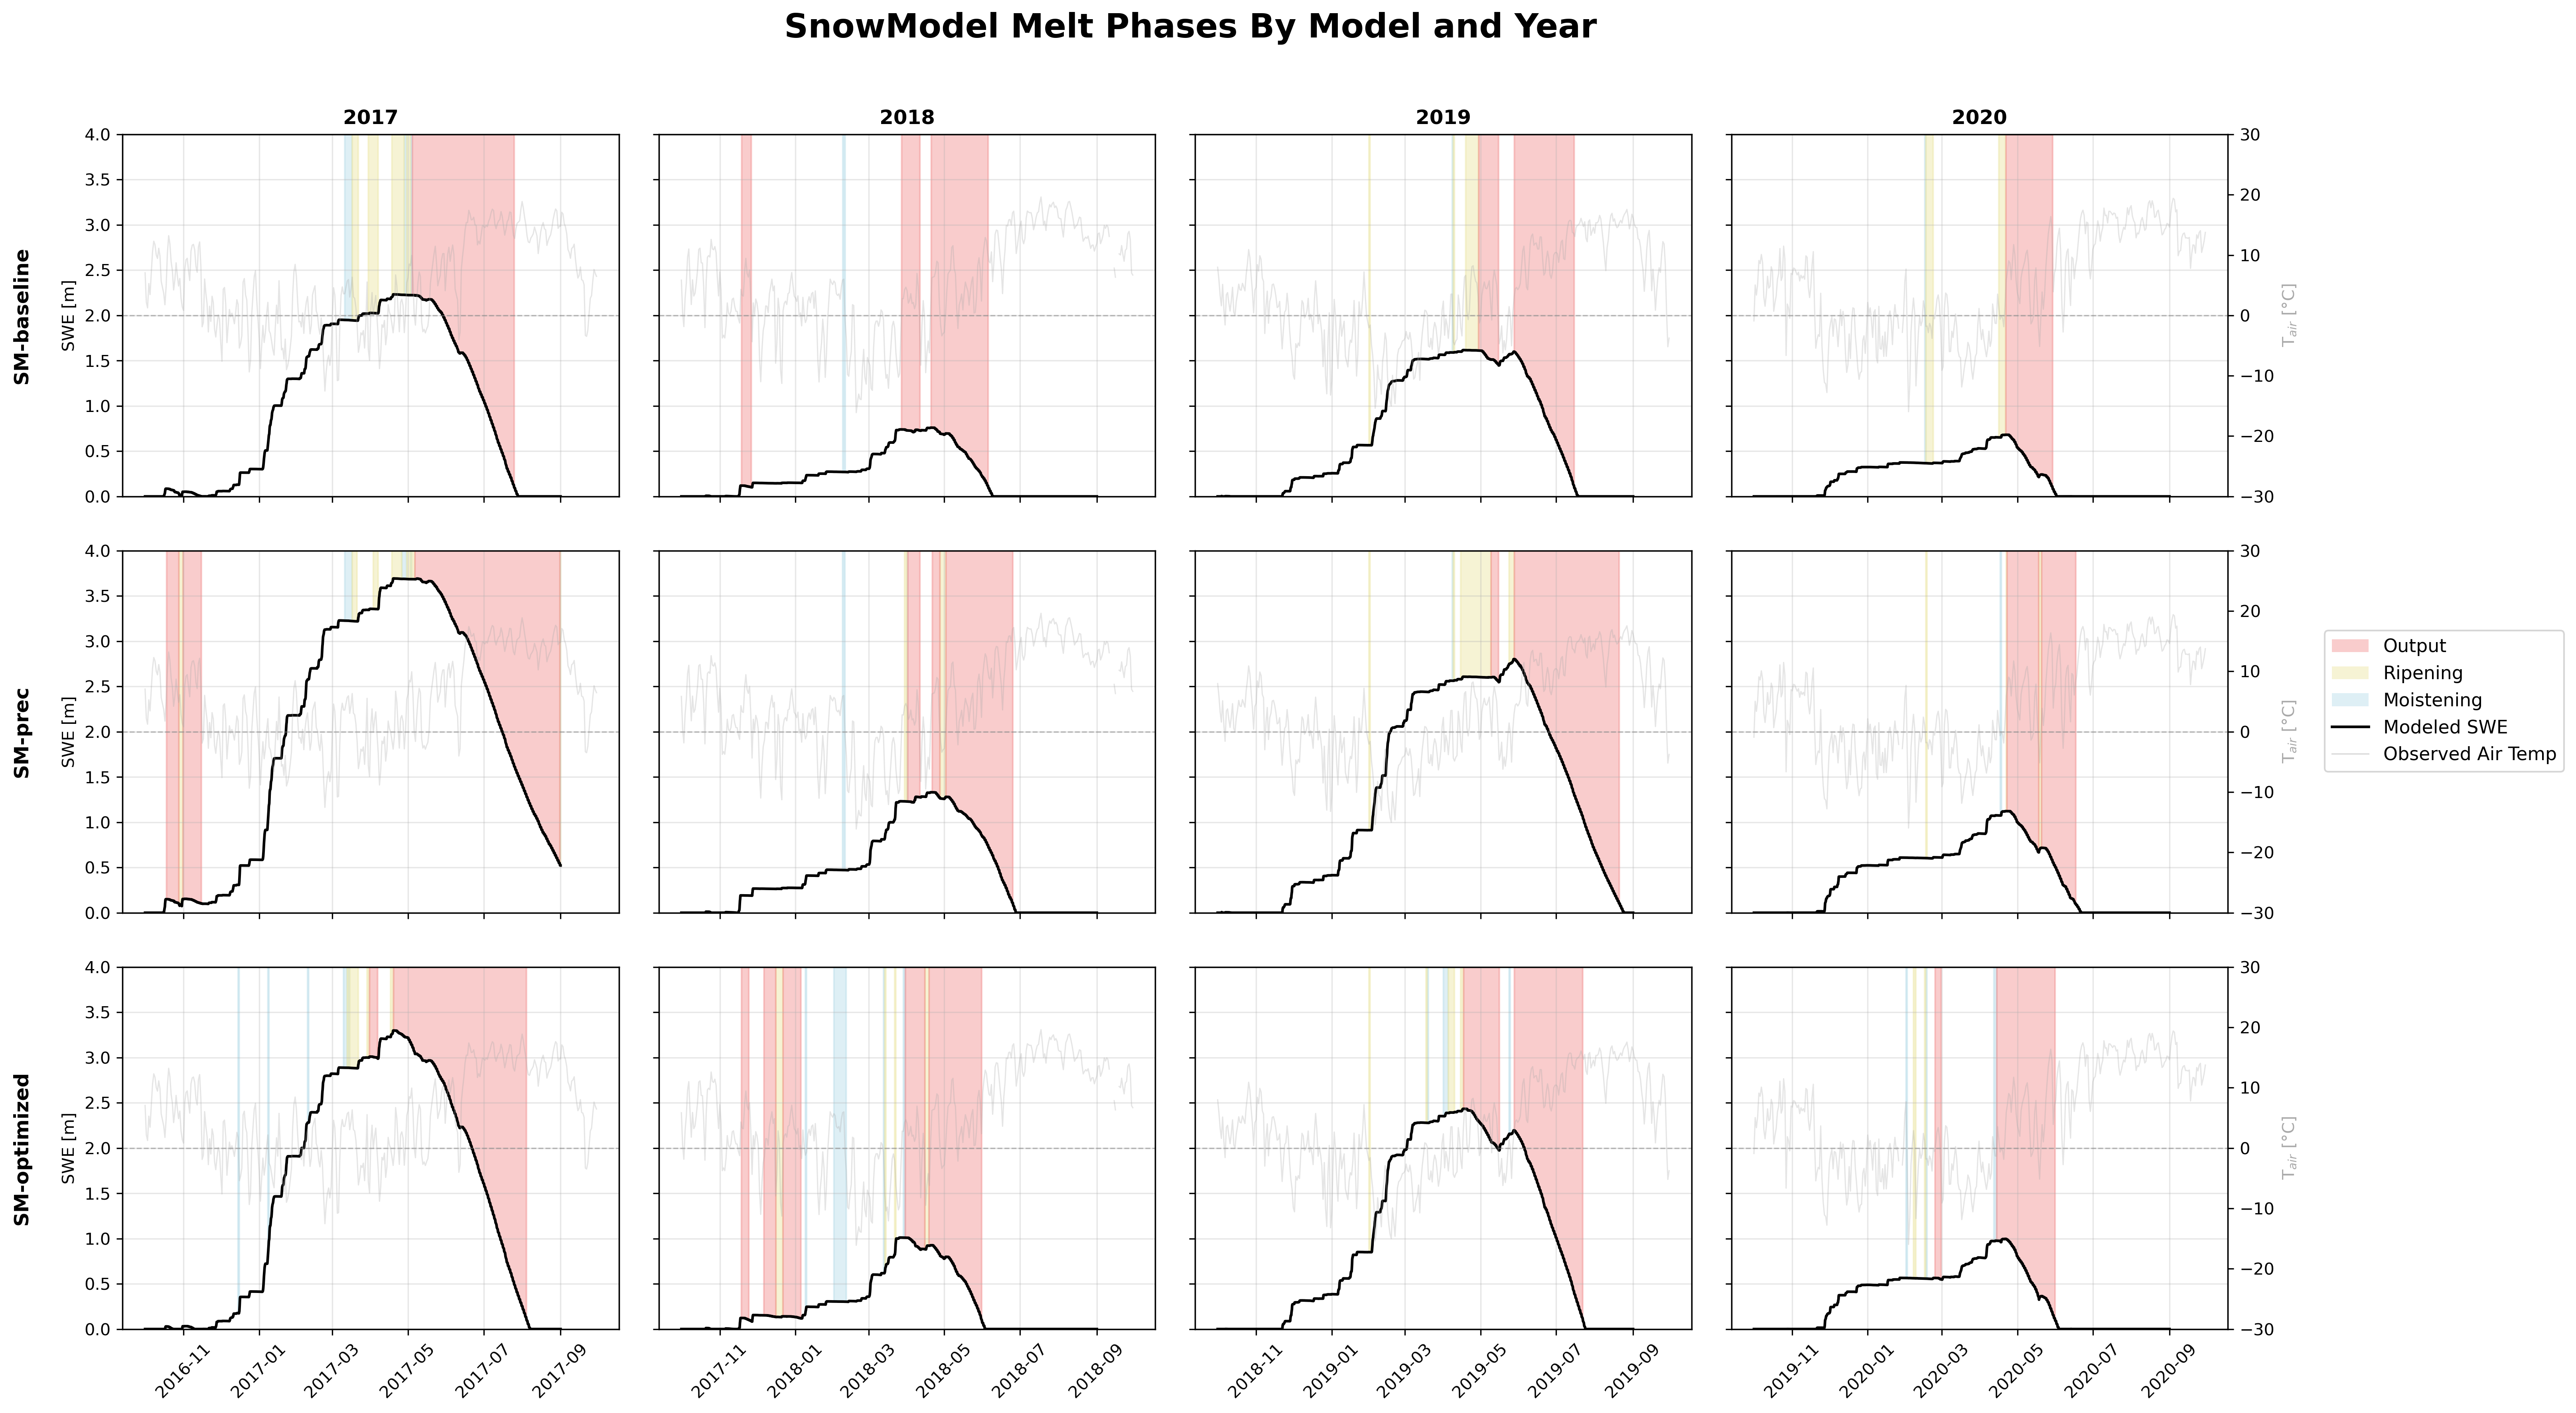

In [74]:
importlib.reload(plotting)
from matplotlib.lines import Line2D

fig, axes = plt.subplots(3, 4, figsize=(20, 12), dpi=300, sharex='col',sharey = True)
row_labels = ["SM-baseline", "SM-prec", "SM-optimized"]
col_years = [2017, 2018, 2019, 2020]
# ylims = [4, 1.5, 3, 1.2]
ylims = [4, 4, 4,4]

for i in range(3):
    leg,_ = plotting.plot_snowmelt_phases_filltop(swe_mod_data_2017[i], phase_rv_data_2017[i], ax=axes[i][0], ylim_=ylims[0], title="")
    leg,_ = plotting.plot_snowmelt_phases_filltop(swe_mod_data_2018[i], phase_rv_data_2018[i], ax=axes[i][1], ylim_=ylims[1], title="")
    leg,_ = plotting.plot_snowmelt_phases_filltop(swe_mod_data_2019[i], phase_rv_data_2019[i], ax=axes[i][2], ylim_=ylims[2], title="")
    leg,_ = plotting.plot_snowmelt_phases_filltop(swe_mod_data_2020[i], phase_rv_data_2020[i], ax=axes[i][3], ylim_=ylims[3], title="")

# Plot air temperature on secondary y-axis and add gray 0°C line
for j in range(4):
    wy = col_years[j]
    df_slice = ds_temp_day.where(ds_temp_day['datetime'] >= np.datetime64(f'{wy-1}-10-01'), drop=True) \
                          .where(ds_temp_day['datetime'] < np.datetime64(f'{wy}-10-01'), drop=True).to_dataframe().reset_index()
    
    for i in range(3):
        ax2 = axes[i][j].twinx()
        # Plot air temperature if available
        if not df_slice.empty:
            ax2.plot(df_slice['datetime'], df_slice['air_temperature'], color='darkgray', alpha=0.3, linewidth=0.75)
        # Always plot 0°C reference line in gray
        ax2.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
        ax2.set_ylim(-30, 30)
        if j == 3:
            ax2.set_ylabel("T$_{air}$ [°C]", color='darkgray')
        else:
            ax2.set_yticklabels([])
            ax2.tick_params(right=False)

for j, yr in enumerate(col_years):
    axes[0][j].set_title(str(yr), fontweight='bold')

# First column: SWE label + row label on the right side
for i, lbl in enumerate(row_labels):
    axes[i][0].set_ylabel("SWE [m]")
    axes[i][0].annotate(lbl, xy=(0, 0.5), xytext=(-55, 0),
                        xycoords='axes fraction', textcoords='offset points',
                        ha='right', va='center', fontweight='bold', fontsize=12,
                        rotation=90)

# Remove y-axis labels for non-first-column subplots
for i in range(3):
    for j in range(1, 4):
        axes[i][j].set_ylabel("")
        axes[i][j].tick_params(labelleft=False)

# Rotate x-tick labels in the last row
for j in range(4):
    axes[2][j].tick_params(axis='x', rotation=45)

# Add SWE and T_air line handles to the legend
leg["Modeled SWE"] = Line2D([0], [0], color='black', linewidth=1.6)
leg["Observed Air Temp"] = Line2D([0], [0], color='gray', alpha=0.3, linewidth=0.75)

plt.suptitle("SnowModel Melt Phases By Model and Year", fontweight='bold', fontsize=20)
fig.tight_layout(rect=[0, 0, 0.97, 0.96])
fig.subplots_adjust(hspace=0.15, wspace=0.08)

fig.legend(leg.values(), leg.keys(), loc='center left', bbox_to_anchor=(0.97, 0.5),
           fontsize=11, frameon=True)

### S-1

#### VV (Nagler 1996)

In [75]:
importlib.reload(melt_phases)

cfg = melt_phases.MarinS1VVCfg(min_stability_days=28,
                              max_group_spread_days=28,
                              max_am_pm_mismatch_days=28
                              )

vv_out_2017 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2017, sentinel_cues_reference_2017, idy_cues, idx_cues, 2017, cfg)
vv_out_2018 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2018, sentinel_cues_reference_2018, idy_cues, idx_cues, 2018, cfg)
vv_out_2019 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2019, sentinel_cues_reference_2019, idy_cues, idx_cues, 2019, cfg)
vv_out_2020 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2020, sentinel_cues_reference_2020, idy_cues, idx_cues, 2020, cfg)

print(vv_out_2017["output_start"], vv_out_2017["qc_ok"], vv_out_2017["qc_reason"])
print(vv_out_2018["output_start"], vv_out_2018["qc_ok"], vv_out_2018["qc_reason"])
print(vv_out_2019["output_start"], vv_out_2019["qc_ok"], vv_out_2019["qc_reason"])
print(vv_out_2020["output_start"], vv_out_2020["qc_ok"], vv_out_2020["qc_reason"])

2017-05-05 07:59:03.969113600 True OK
NaT False NO_GOOD_MORNING_ORBIT
NaT False AM_PM_MINIMA_MISMATCH
NaT False AM_PM_MINIMA_MISMATCH


#### Weighted Combination (Nagler 2016)

In [76]:
import importlib
import sys

# Force complete reimport of melt_phases module
for mod in list(sys.modules.keys()):
    if 'melt_phases' in mod:
        del sys.modules[mod]

import melt_phases
importlib.reload(melt_phases)
importlib.reload(plotting)

path_2017 = "/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2017/melt_thresh/data/datasets/"
path_2018 = "/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2018/melt_thresh/data/datasets/"
path_2019 = "/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2019/melt_thresh/data/datasets/"
path_2020 = "/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2020/melt_thresh/data/datasets/"
cfg_marin = melt_phases.MarinS1VVCfg(
    tau_db=-2.0,
    min_stability_days=28,
    max_group_spread_days=28,
    max_am_pm_mismatch_days=28,
)

cfg_w = melt_phases.WeightedMinimaCfg(
    k=0.5, theta1=20, theta2=45,
    wet_thresh_db=-2.0,
    cfg_marin=cfg_marin,
)

weighted_out_2017 = melt_phases.run_s1_rc_minima_year(path_2017, cues_y, cues_x, 2017, cfg_w)
weighted_out_2018 = melt_phases.run_s1_rc_minima_year(path_2018, cues_y, cues_x, 2018, cfg_w)
weighted_out_2019 = melt_phases.run_s1_rc_minima_year(path_2019, cues_y, cues_x, 2019, cfg_w)
weighted_out_2020 = melt_phases.run_s1_rc_minima_year(path_2020, cues_y, cues_x, 2020, cfg_w)

print(weighted_out_2017["output_start"], weighted_out_2017["qc_ok"], weighted_out_2017["qc_reason"])
print(weighted_out_2018["output_start"], weighted_out_2018["qc_ok"], weighted_out_2018["qc_reason"])
print(weighted_out_2019["output_start"], weighted_out_2019["qc_ok"], weighted_out_2019["qc_reason"])
print(weighted_out_2020["output_start"], weighted_out_2020["qc_ok"], weighted_out_2020["qc_reason"])

NaT False NO_GOOD_MORNING_ORBIT
NaT False NO_GOOD_MORNING_ORBIT
2019-05-07 13:57:27.735835136 True OK
NaT False NO_GOOD_MORNING_ORBIT


### Combined S-1

In [77]:
# Revamp data lists (same structure as original for comparison)
phase_s1_data_2017 = [vv_out_2017["phases"], weighted_out_2017["phases"]]
phase_s1_data_2018 = [vv_out_2018["phases"], weighted_out_2018["phases"]]
phase_s1_data_2019 = [vv_out_2019["phases"], weighted_out_2019["phases"]]
phase_s1_data_2020 = [vv_out_2020["phases"], weighted_out_2020["phases"]]

swe_obs_data_2017 = [cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2016-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2017-10-01'),drop = True),
                  cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2016-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2017-10-01'),drop = True)]
swe_obs_data_2018 = [cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2017-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2018-10-01'),drop = True),
                  cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2017-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2018-10-01'),drop = True)]
swe_obs_data_2019 = [cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2018-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2019-10-01'),drop = True),
                  cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2018-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2019-10-01'),drop = True)]
swe_obs_data_2020 = [cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2019-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2020-10-01'),drop = True),
                  cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2019-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2020-10-01'),drop = True)]


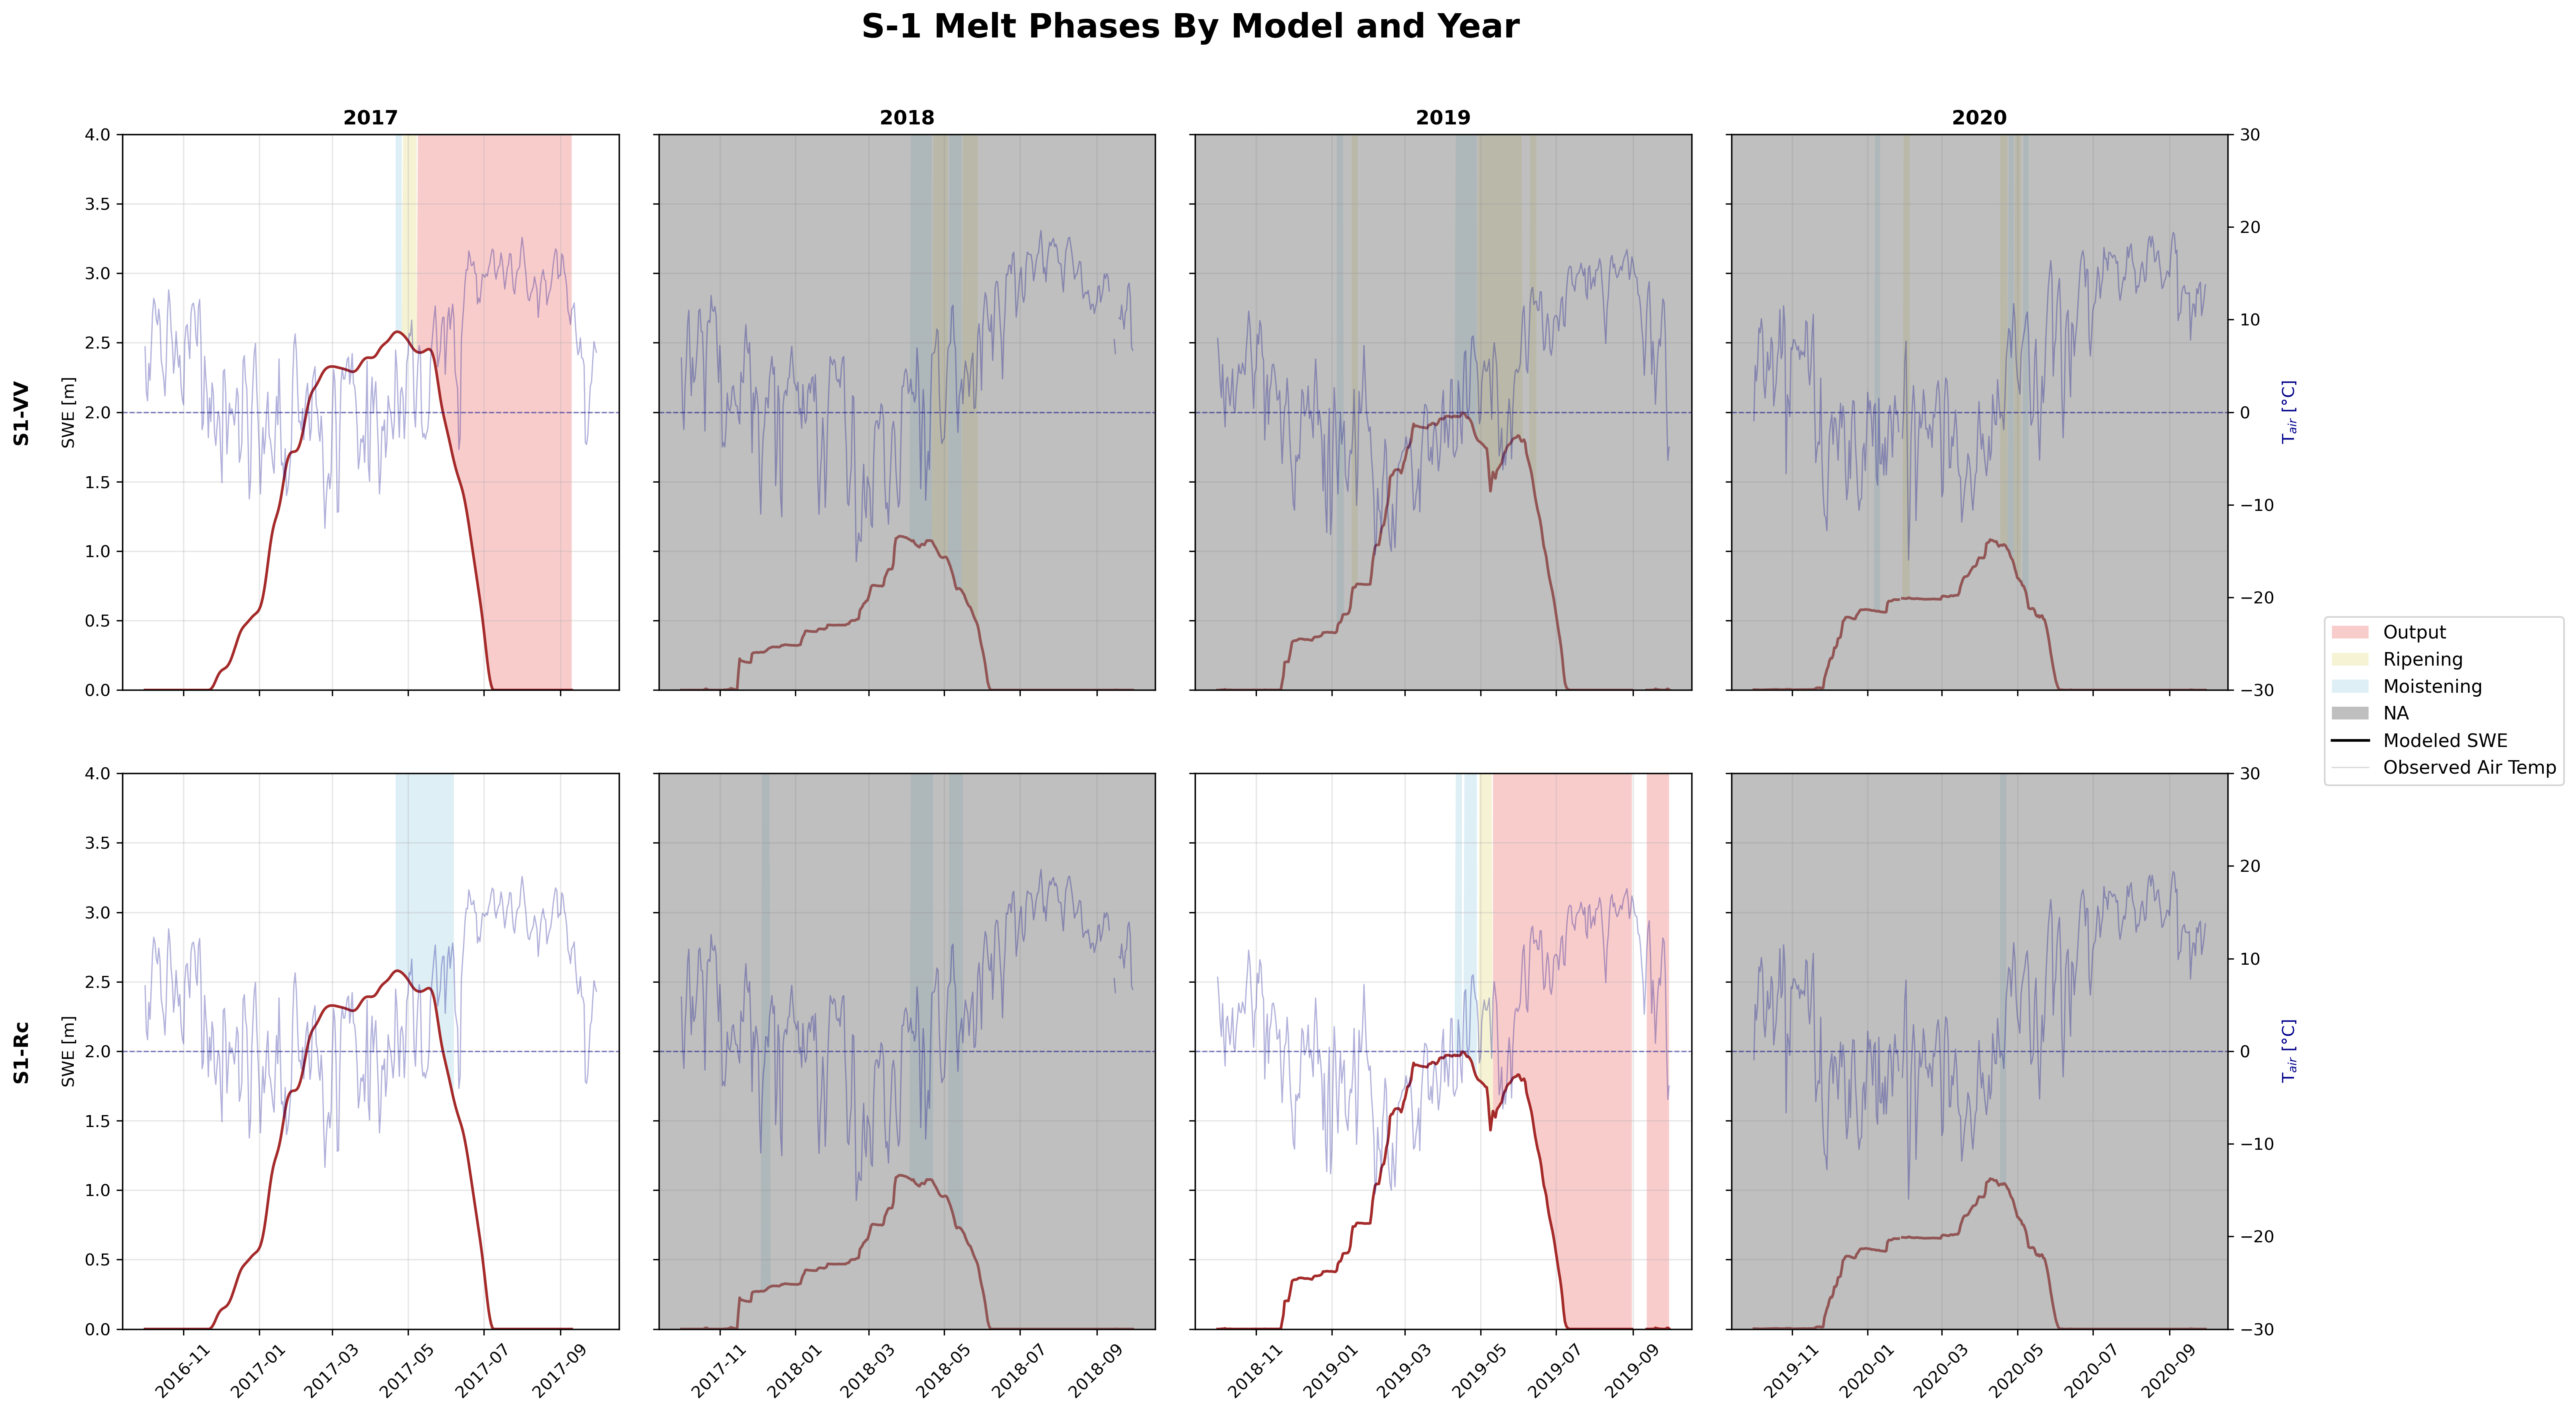

In [78]:
importlib.reload(plotting)
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(2, 4, figsize=(20, 12), dpi=300, sharex='col',sharey = True)
row_labels = ["S1-VV", "S1-Rc"]
col_years = [2017, 2018, 2019, 2020]
# ylims = [4, 1.5, 3, 1.2]
ylims = [4, 4, 4, 4]

for i in range(2):
    leg,_ = plotting.plot_melt_phases_intervals_filltop(swe_obs_data_2017[i], phase_s1_data_2017[i], ax=axes[i][0], ylim_=ylims[0], title="")
    leg,_ = plotting.plot_melt_phases_intervals_filltop(swe_obs_data_2018[i], phase_s1_data_2018[i], ax=axes[i][1], ylim_=ylims[1], title="")
    leg,_ = plotting.plot_melt_phases_intervals_filltop(swe_obs_data_2019[i], phase_s1_data_2019[i], ax=axes[i][2], ylim_=ylims[2], title="")
    leg,_ = plotting.plot_melt_phases_intervals_filltop(swe_obs_data_2020[i], phase_s1_data_2020[i], ax=axes[i][3], ylim_=ylims[3], title="")

# Plot air temperature on secondary y-axis and add gray 0°C line
for j in range(4):
    wy = col_years[j]
    df_slice = ds_temp_day.where(ds_temp_day['datetime'] >= np.datetime64(f'{wy-1}-10-01'), drop=True) \
                          .where(ds_temp_day['datetime'] < np.datetime64(f'{wy}-10-01'), drop=True).to_dataframe().reset_index()
    
    for i in range(2):
        ax2 = axes[i][j].twinx()
        # Plot air temperature if available
        if not df_slice.empty:
            ax2.plot(df_slice['datetime'], df_slice['air_temperature'], color='darkblue', alpha=0.3, linewidth=0.75)
        # Always plot 0°C reference line in gray
        ax2.axhline(0, color='darkblue', linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
        ax2.set_ylim(-30, 30)
        if j == 3:
            ax2.set_ylabel("T$_{air}$ [°C]", color='darkblue')
        else:
            ax2.set_yticklabels([])
            ax2.tick_params(right=False)

for j, yr in enumerate(col_years):
    axes[0][j].set_title(str(yr), fontweight='bold')

# First column: SWE label + row label on the right side
for i, lbl in enumerate(row_labels):
    axes[i][0].set_ylabel("SWE [m]")
    axes[i][0].annotate(lbl, xy=(0, 0.5), xytext=(-55, 0),
                        xycoords='axes fraction', textcoords='offset points',
                        ha='right', va='center', fontweight='bold', fontsize=12,
                        rotation=90)

# Remove y-axis labels for non-first-column subplots
for i in range(2):
    for j in range(1, 4):
        axes[i][j].set_ylabel("")
        axes[i][j].tick_params(labelleft=False)

# Rotate x-tick labels in the last row
for j in range(4):
    axes[-1][j].tick_params(axis='x', rotation=45)


gray_out = [(0, 1),(0,2),(0,3),(1,1),(1,3)]  # (row, col) pairs to gray out — add more as needed
for r, c in gray_out:
    axes[r][c].add_patch(Rectangle((0, 0), 1, 1, transform=axes[r][c].transAxes,
                                   facecolor='gray', alpha=0.5, zorder=100))

# Add SWE and T_air line handles to the legend
leg["NA"] = Patch(facecolor='gray', alpha=0.5)
leg["Modeled SWE"] = Line2D([0], [0], color='black', linewidth=1.6)
leg["Observed Air Temp"] = Line2D([0], [0], color='gray', alpha=0.3, linewidth=0.75)

plt.suptitle("S-1 Melt Phases By Model and Year", fontweight='bold', fontsize=20)
fig.tight_layout(rect=[0, 0, 0.97, 0.96])
fig.subplots_adjust(hspace=0.15, wspace=0.08)

fig.legend(leg.values(), leg.keys(), loc='center left', bbox_to_anchor=(0.97, 0.5),
           fontsize=11, frameon=True)

### Combined SM/S-1

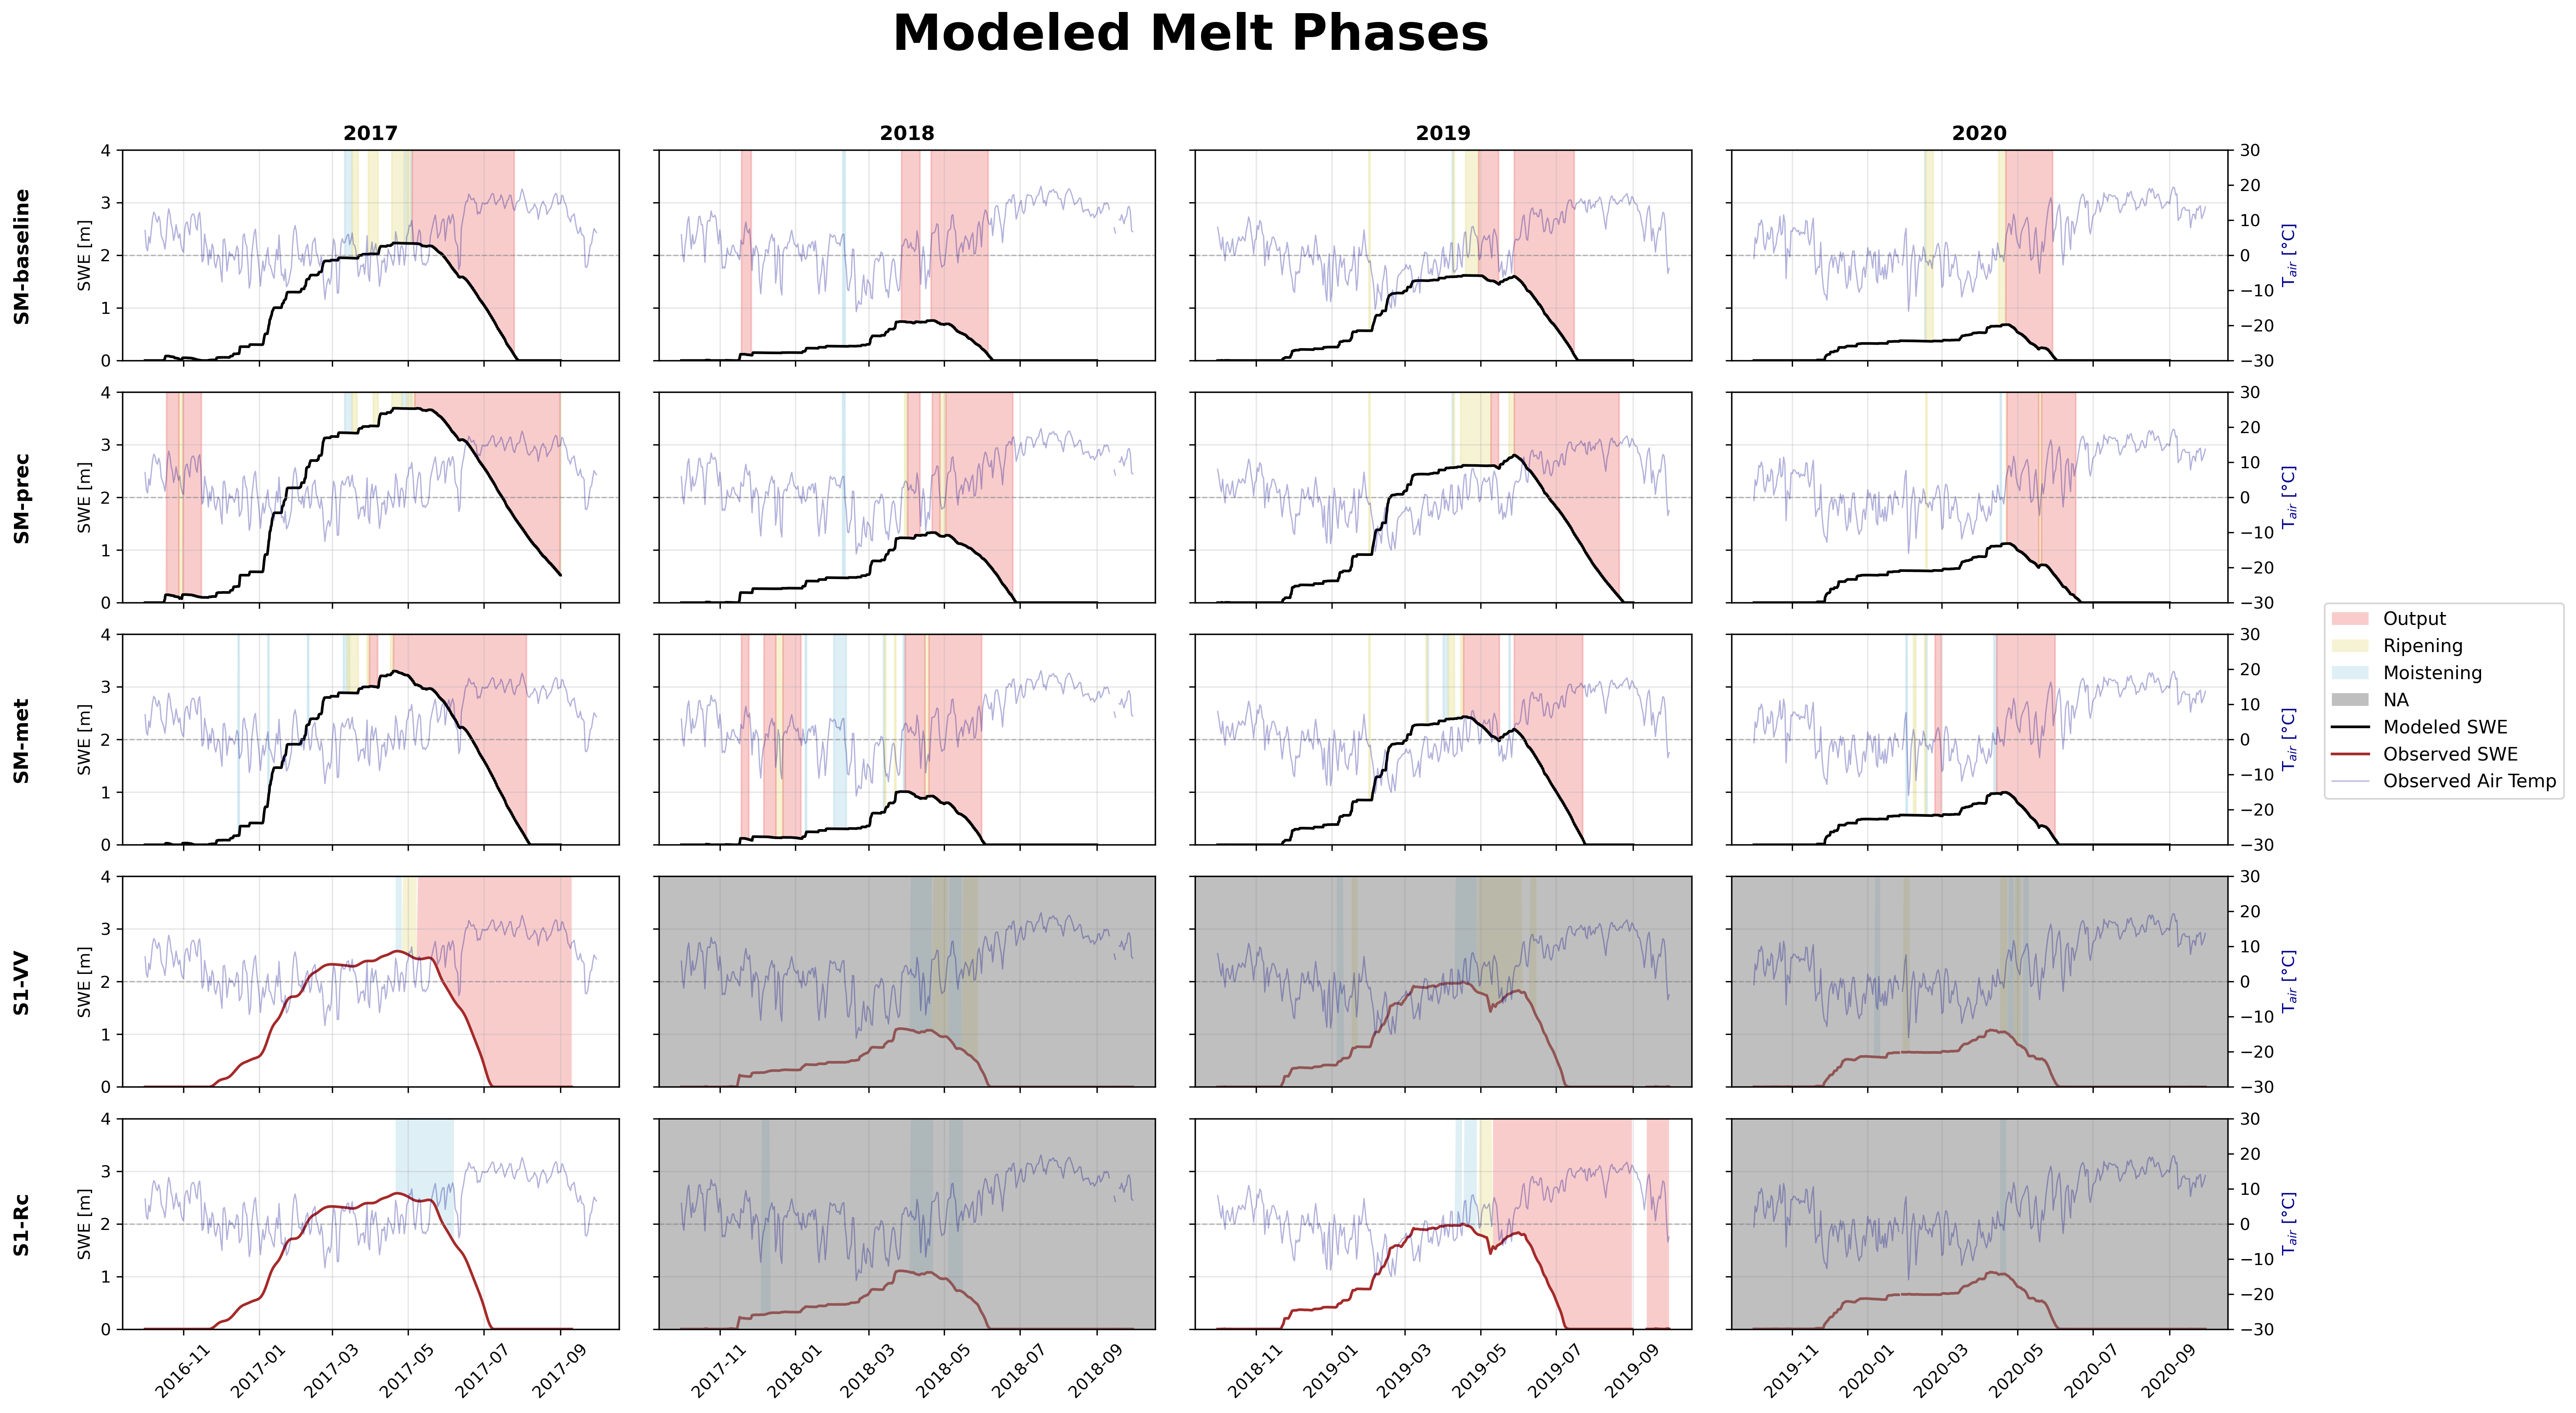

In [79]:
importlib.reload(plotting)
from matplotlib.lines import Line2D

fig, axes = plt.subplots(5, 4, figsize=(20, 12), dpi=300, sharex='col',sharey = True)
row_labels = ["SM-baseline", "SM-prec", "SM-met","S1-VV","S1-Rc"]
col_years = [2017, 2018, 2019, 2020]
# ylims = [4, 1.5, 3, 1.2]
ylims = [4, 4, 4, 4]

for j in range(3):
    leg,_ = plotting.plot_snowmelt_phases_filltop(swe_mod_data_2017[j], phase_rv_data_2017[j], ax=axes[j][0], ylim_=ylims[0], title="")
    leg,_ = plotting.plot_snowmelt_phases_filltop(swe_mod_data_2018[j], phase_rv_data_2018[j], ax=axes[j][1], ylim_=ylims[1], title="")
    leg,_ = plotting.plot_snowmelt_phases_filltop(swe_mod_data_2019[j], phase_rv_data_2019[j], ax=axes[j][2], ylim_=ylims[2], title="")
    leg,_ = plotting.plot_snowmelt_phases_filltop(swe_mod_data_2020[j], phase_rv_data_2020[j], ax=axes[j][3], ylim_=ylims[3], title="")

j += 1
for i in range(2):
    leg,_ = plotting.plot_melt_phases_intervals_filltop(swe_obs_data_2017[i], phase_s1_data_2017[i], ax=axes[i+j][0], ylim_=ylims[0], title="")
    leg,_ = plotting.plot_melt_phases_intervals_filltop(swe_obs_data_2018[i], phase_s1_data_2018[i], ax=axes[i+j][1], ylim_=ylims[1], title="")
    leg,_ = plotting.plot_melt_phases_intervals_filltop(swe_obs_data_2019[i], phase_s1_data_2019[i], ax=axes[i+j][2], ylim_=ylims[2], title="")
    leg,_ = plotting.plot_melt_phases_intervals_filltop(swe_obs_data_2020[i], phase_s1_data_2020[i], ax=axes[i+j][3], ylim_=ylims[3], title="")

# Plot air temperature on secondary y-axis and add gray 0°C line
for j in range(4):
    wy = col_years[j]
    df_slice = ds_temp_day.where(ds_temp_day['datetime'] >= np.datetime64(f'{wy-1}-10-01'), drop=True) \
                          .where(ds_temp_day['datetime'] < np.datetime64(f'{wy}-10-01'), drop=True).to_dataframe().reset_index()
    
    for i in range(5):
        ax2 = axes[i][j].twinx()
        # Plot air temperature if available
        if not df_slice.empty:
            ax2.plot(df_slice['datetime'], df_slice['air_temperature'], color='darkblue', alpha=0.3, linewidth=0.75)
        # Always plot 0°C reference line in gray
        ax2.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
        ax2.set_ylim(-30, 30)
        if j == 3:
            ax2.set_ylabel("T$_{air}$ [°C]", color='darkblue')
        else:
            ax2.set_yticklabels([])
            ax2.tick_params(right=False)

for j, yr in enumerate(col_years):
    axes[0][j].set_title(str(yr), fontweight='bold')

# First column: SWE label + row label on the right side
for i, lbl in enumerate(row_labels):
    axes[i][0].set_ylabel("SWE [m]")
    axes[i][0].annotate(lbl, xy=(0, 0.5), xytext=(-55, 0),
                        xycoords='axes fraction', textcoords='offset points',
                        ha='right', va='center', fontweight='bold', fontsize=12,
                        rotation=90)

# Remove y-axis labels for non-first-column subplots
for i in range(5):
    for j in range(1, 4):
        axes[i][j].set_ylabel("")
        axes[i][j].tick_params(labelleft=False)

# Rotate x-tick labels in the last row
for j in range(4):
    axes[-1][j].tick_params(axis='x', rotation=45)

# Add SWE and T_air line handles to the legend
from matplotlib.patches import Patch
leg["NA"] = Patch(facecolor='gray', alpha=0.5)
leg["Modeled SWE"] = Line2D([0], [0], color='black', linewidth=1.6)
leg["Observed SWE"] = Line2D([0], [0], color='brown', linewidth=1.6)
leg["Observed Air Temp"] = Line2D([0], [0], color='darkblue', alpha=0.3, linewidth=0.75)

plt.suptitle("Modeled Melt Phases", fontweight='bold', fontsize=30)
fig.tight_layout(rect=[0, 0, 0.97, 0.96])
fig.subplots_adjust(hspace=0.15, wspace=0.08)

# Gray-out selected subplots
from matplotlib.patches import Rectangle
gray_out = [(3, 1),(3,2),(3,3),(4,1),(4,3)]  # (row, col) pairs to gray out — add more as needed
for r, c in gray_out:
    axes[r][c].add_patch(Rectangle((0, 0), 1, 1, transform=axes[r][c].transAxes,
                                   facecolor='gray', alpha=0.5, zorder=100))

fig.legend(leg.values(), leg.keys(), loc='center left', bbox_to_anchor=(0.97, 0.5),
           fontsize=11, frameon=True)

## Comparison

### Multiple Water Year

In [80]:
# daily phase series, already normalized to allowed labels
# index must be daily DatetimeIndex
phases_by_year = {
    2017: {
            "S1-VV": vv_out_2017,  # Pass entire Sentinel dict (includes qc_ok)
            "S1-Rc": weighted_out_2017,  # Pass entire Sentinel dict
            "SM-raw": ph_rv_biased_2017, 
            "SM-prec": ph_rv_prec_ADJ_2017,
            "SM-met": ph_rv_optimized_2017,
    },
    2018: {
        "S1-VV": vv_out_2018, 
        "S1-Rc": weighted_out_2018,
        "SM-raw": ph_rv_biased_2018, 
        "SM-prec": ph_rv_prec_ADJ_2018, 
        "SM-met": ph_rv_optimized_2018,
        },
    2019: {
        "S1-VV": vv_out_2019, 
        "S1-Rc": weighted_out_2019,
        "SM-raw": ph_rv_biased_2019, 
        "SM-prec": ph_rv_prec_ADJ_2019, 
        "SM-met": ph_rv_optimized_2019,
        },
    2020: {
        "S1-VV": vv_out_2020, 
        "S1-Rc": weighted_out_2020,
        "SM-raw": ph_rv_biased_2020, 
        "SM-prec": ph_rv_prec_ADJ_2020, 
        "SM-met": ph_rv_optimized_2020,
        },
}


#### Figure 4

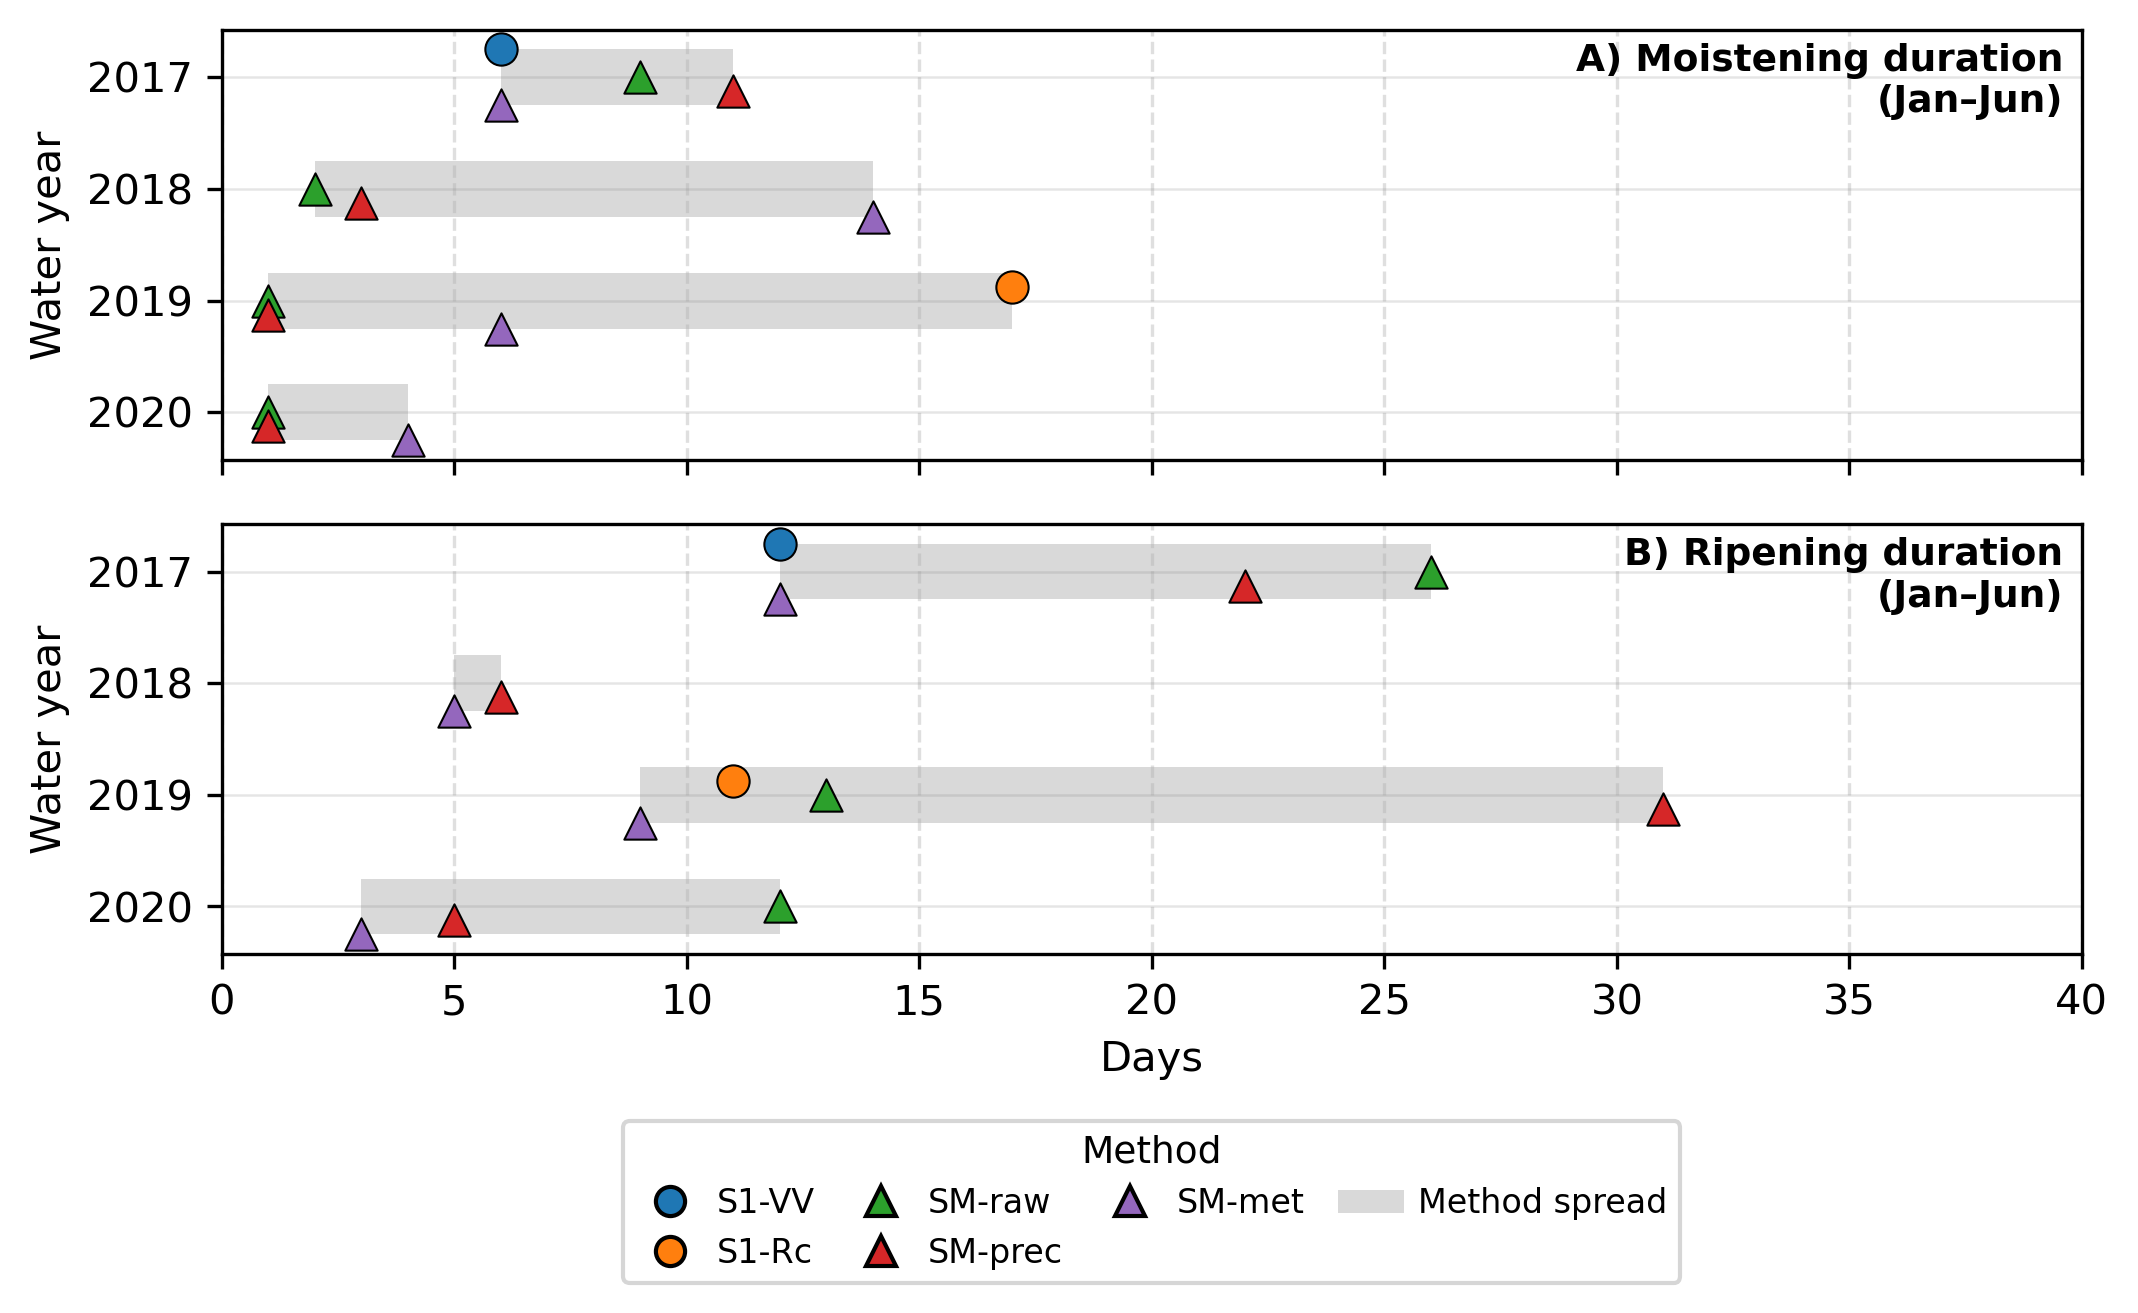

In [81]:
importlib.reload(fig_2b)

metrics = fig_2b.compute_phase_metrics(
    phases_by_year,
    method_order=["S1-VV", "S1-Rc", "SM-raw", "SM-prec", "SM-met"],
    window_md=("01-01", "08-01"),
    min_consecutive_days_onset=20,
    method_markers={
        'S1-VV': 'o', 'S1-Rc': 'o',
        'SM-raw': '^', 'SM-prec': '^', 'SM-met': '^'},
)

fig1, (axA, axB) = fig_2b.plot_duration_panels(metrics, plotInsetTitle=True, figsize=(8, 4), dpi=300)
plt.show()


#### Figure 5

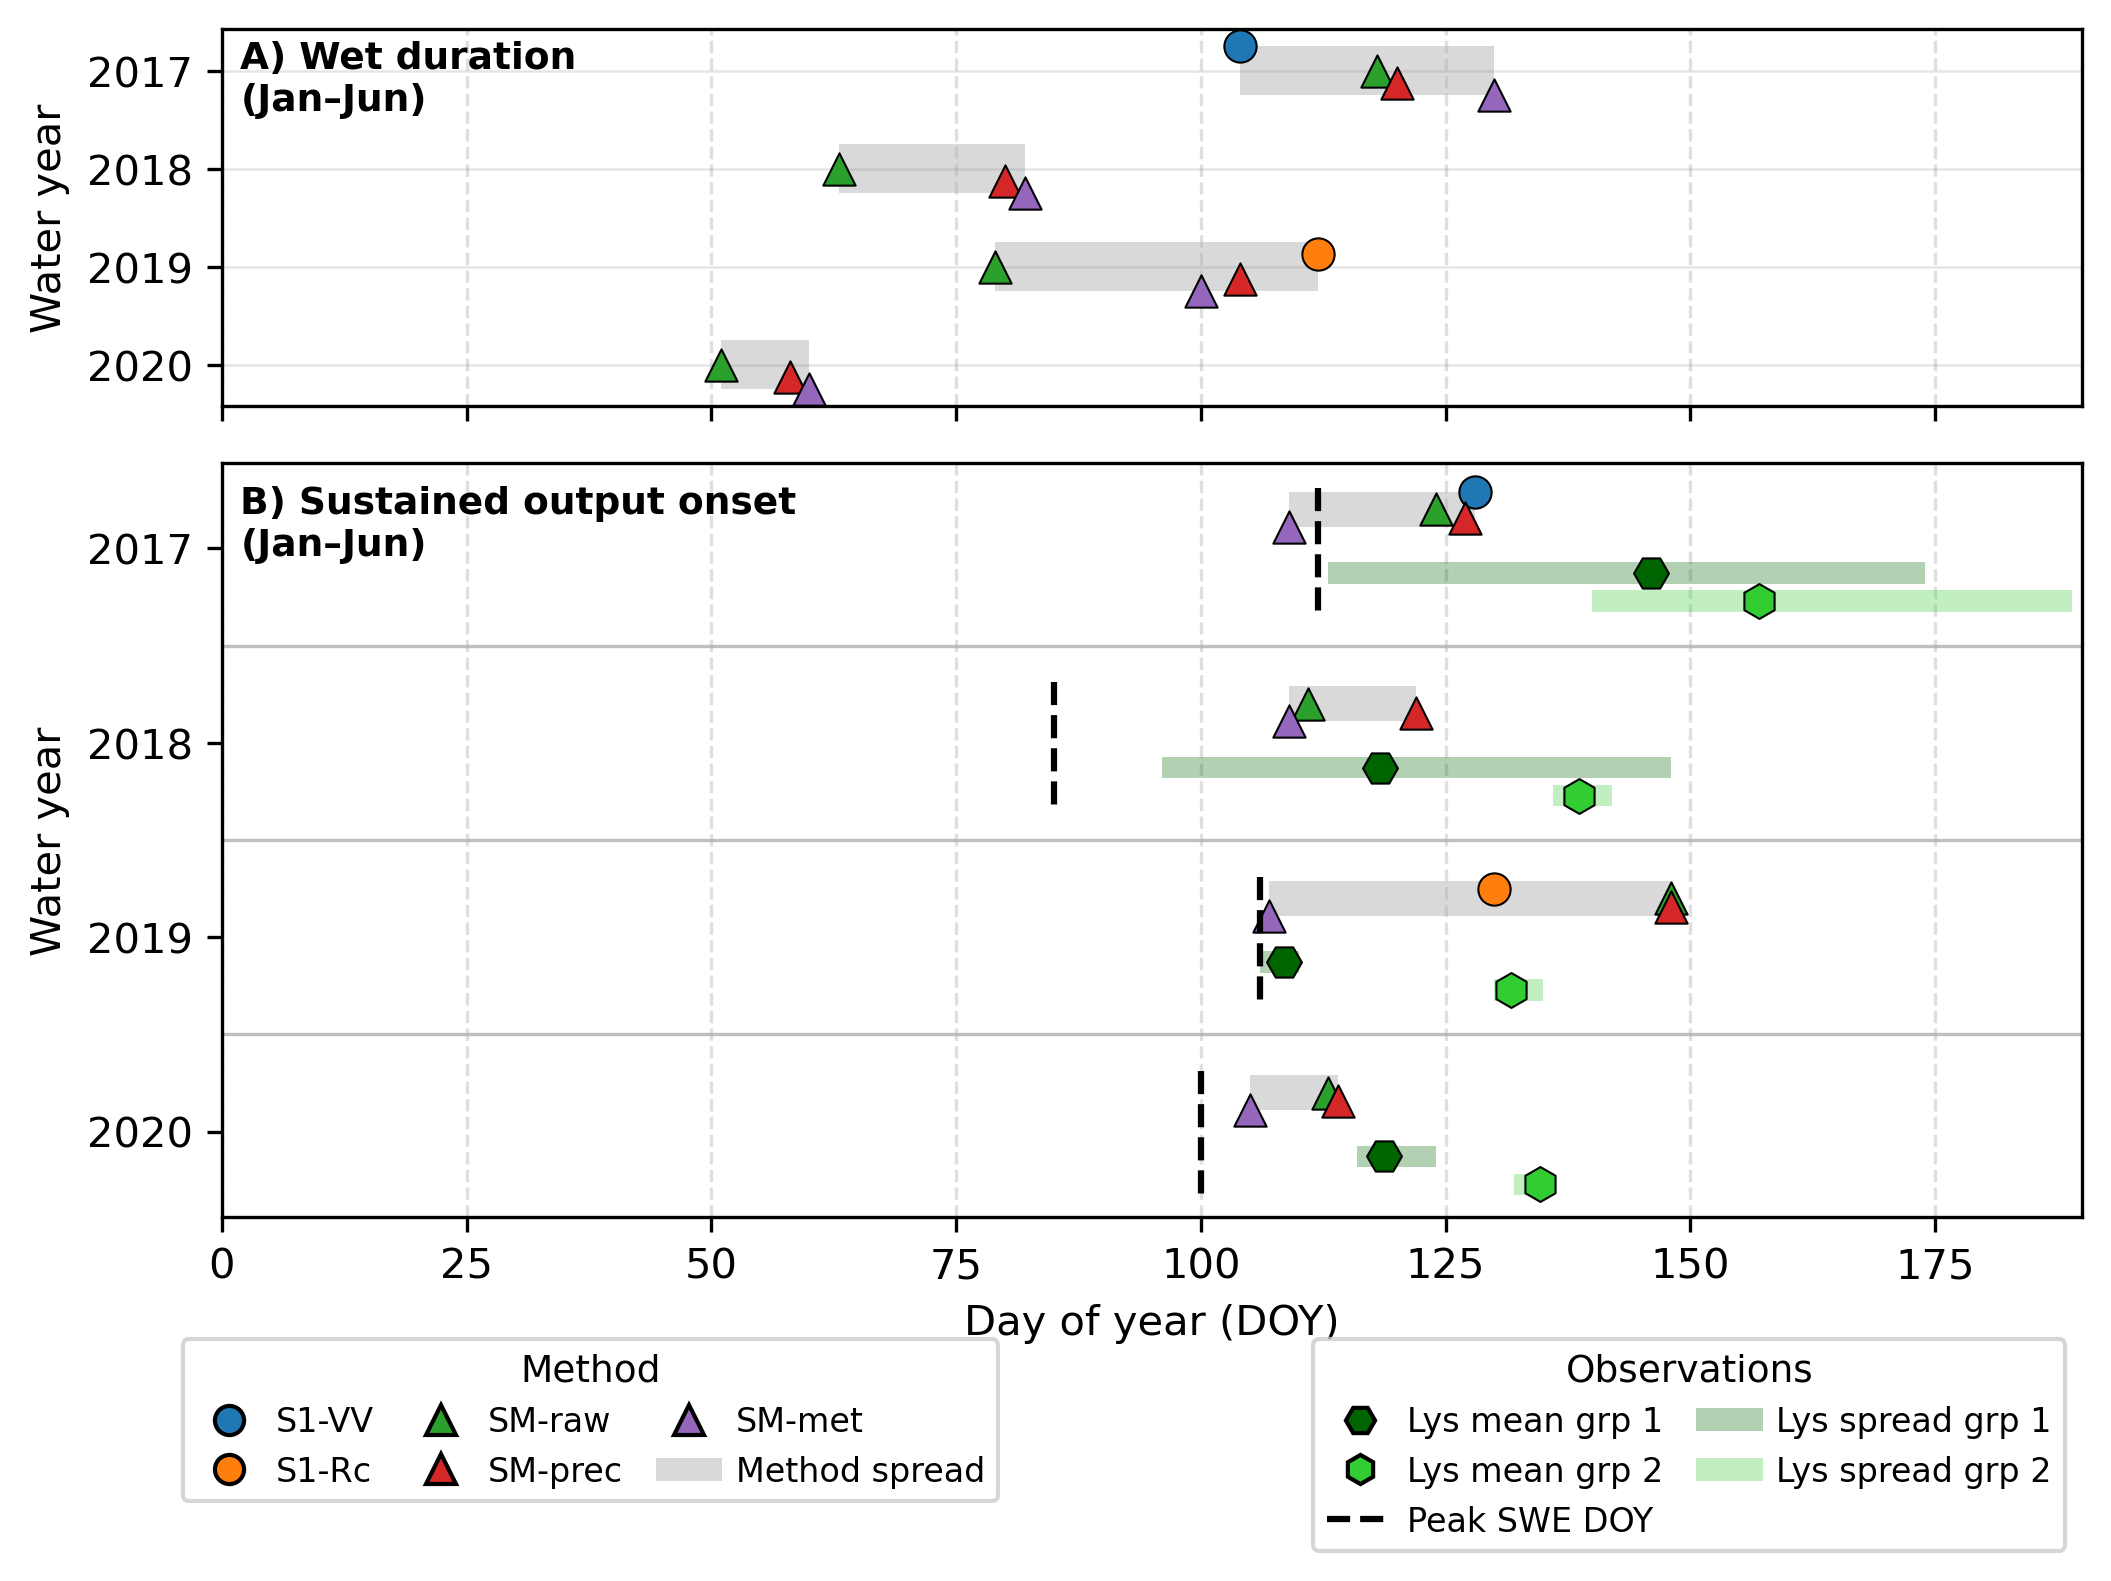

In [82]:
fig2, (axC, axD), onset_table = fig_2b.plot_onset_panels(
    metrics,
    df_lys=df_lys,
    lys_threshold=0.6,
    lys_min_consecutive_days=2,
    swe_ds=cues_swe_m_ds,
    plotInsetTitle=True,
    figsize=(8, 6),
    dpi=300,
)
plt.show()

#### Sustained Output Onset Table

### Method

Lysimeter meltwater output was recorded by tipping-bucket lysimeters at JDSSS, grouped by aspect into a north-facing group (Lys-1; tubes tb5–tb8, n ≤ 4) and a south-facing group (Lys-2; tubes tb1–tb3, n ≤ 3). Hourly tipping-bucket data were aggregated to daily meltwater sums. Sustained draining phase onset for each tube was defined as the first day of a minimum of two consecutive days with a daily meltwater sum ≥ 0.6 mm day⁻¹, within a January 1–August 1 search window. The group onset date was summarized as the mean and range across all tubes with a valid detection. Tubes with no exceedance of the threshold within the window were excluded from group statistics, and the number of valid tubes (n) is reported.

For SnowModel, sustained draining phase onset was defined as the first day of ≥ 20 consecutive days classified in the output phase. Sentinel-1 onset dates are derived from the S1-VV (Nagler 1996) and S1-Rc (Nagler 2016) algorithms; years where orbit QC criteria were not met are reported as unavailable (—).

---

### Table S4 — Sustained draining phase onset timing at JDSSS (WY 2017–2020)

| WY | Peak SWE date (DOY) | SM-raw (DOY) | SM-prec (DOY) | SM-optimized (DOY) | S1-VV (DOY) | S1-Rc (DOY) | Lys-1 mean (DOY) | Lys-1 range | Lys-1 n | Lys-2 mean (DOY) | Lys-2 range | Lys-2 n |
|----|---------------------|--------------|---------------|--------------------|-------------|-------------|------------------|-------------|---------|------------------|-------------|---------|
| 2017 | Apr 22 (112) | May 04 (124) | May 07 (127) | Apr 19 (109) | May 08 (128) | May 08 (128) | May 26 (146) | 113–174 | 4 | Jun 06 (157) | 140–189 | 3 |
| 2018 | Mar 26 (85) | Apr 21 (111) | May 02 (122) | Apr 19 (109) | — | — | Apr 28 (118) | 96–148 | 3 | May 19 (139) | 136–142 | 3 |
| 2019 | Apr 16 (106) | May 28 (148) | May 28 (148) | Apr 17 (107) | — | May 17 (137) | Apr 19 (109) | 106–110 | 4 | May 12 (132) | 130–135 | 3 |
| 2020 | Apr 09 (100) | Apr 22 (113) | Apr 23 (114) | Apr 14 (105) | — | — | Apr 28 (119) | 116–124 | 4 | May 14 (135) | 132–136 | 3 |
| **Mean** | | **124** | **128** | **108** | 128† | 133‡ | **123** | | | **141** | | |

*† 2017 only. ‡ 2017 and 2019 only. Lys-1 = north-facing tipping-bucket group; Lys-2 = south-facing tipping-bucket group. n = number of tubes with valid onset detection.*

# Appendix

## Lysimeter investigation

=== Summary statistics (Jan-Jun) ===
         tb5_north    tb6_north    tb7_north    tb8_north    tb1_south  \
count  3625.000000  3625.000000  3625.000000  3625.000000  3625.000000   
mean      0.233291     0.182334     0.294643     0.281203     0.233247   
std       2.831797     2.603528     2.727569     3.651975     1.032496   
min       0.000000     0.000000     0.000000     0.000000     0.000000   
25%       0.000000     0.000000     0.000000     0.000000     0.000000   
50%       0.000000     0.000000     0.000000     0.000000     0.000000   
75%       0.000000     0.000000     0.000000     0.000000     0.000000   
max      82.960000   124.000000    82.640000   124.480000    11.040000   

         tb2_south    tb3_south    tb4_south  
count  3625.000000  3625.000000  3625.000000  
mean      0.165032     0.425203     0.006157  
std       1.122515     7.371215     0.340325  
min       0.000000     0.000000     0.000000  
25%       0.000000     0.000000     0.000000  
50%       0.00

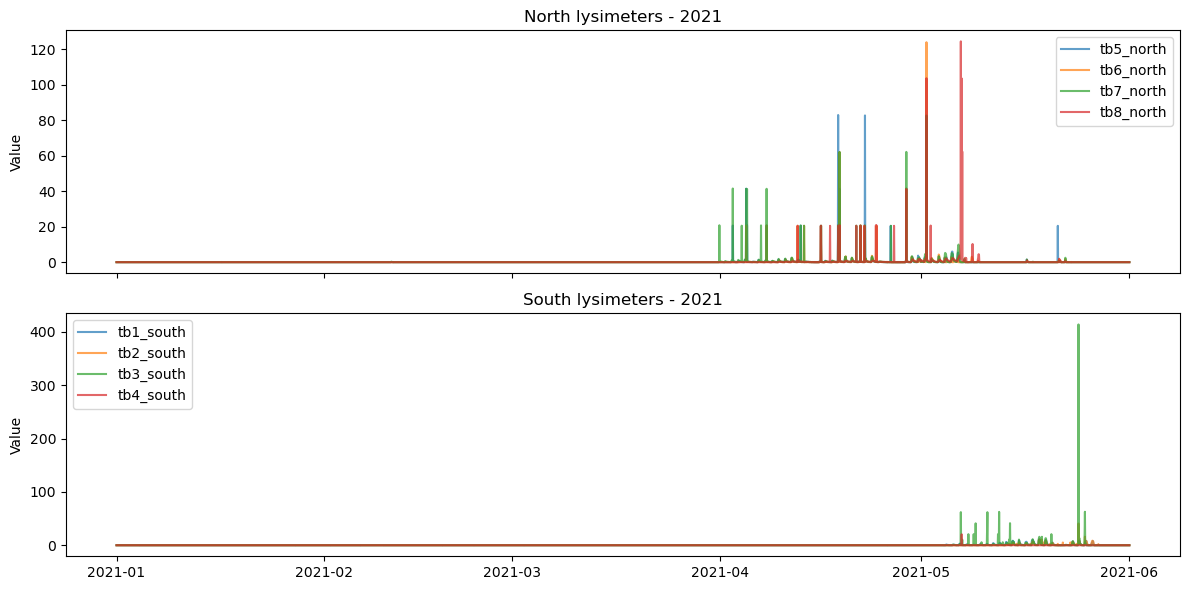


=== Non-zero value distribution ===
tb5_north: min=0.08, median=0.16, mean=1.22
tb6_north: min=0.08, median=0.16, mean=0.98
tb7_north: min=0.08, median=0.16, mean=1.29
tb8_north: min=0.08, median=0.24, mean=1.53
tb1_south: min=0.08, median=0.32, mean=1.19
tb2_south: min=0.08, median=0.24, mean=1.55
tb3_south: min=0.08, median=0.40, mean=3.58
tb4_south: min=0.08, median=0.16, mean=2.23


In [83]:
# Investigate lysimeter data for melt onset threshold

plotCols_N = ['tb5_north','tb6_north','tb7_north','tb8_north']
plotCols_S = ['tb1_south','tb2_south','tb3_south','tb4_south']

# Look at data for a specific year to understand the signal
year = 2021
start_date = f"{year}-01-01"
end_date = f"{year}-06-01"

df_yr = df_lys[(df_lys['datetime'] >= start_date) & (df_lys['datetime'] <= end_date)].copy()

# Basic stats
print("=== Summary statistics (Jan-Jun) ===")
print(df_yr[plotCols_N + plotCols_S].describe())

# Plot time series to visualize the signal
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for col in plotCols_N:
    axes[0].plot(df_yr['datetime'], df_yr[col], alpha=0.7, label=col)
axes[0].set_title(f'North lysimeters - {year}')
axes[0].legend()
axes[0].set_ylabel('Value')

for col in plotCols_S:
    axes[1].plot(df_yr['datetime'], df_yr[col], alpha=0.7, label=col)
axes[1].set_title(f'South lysimeters - {year}')
axes[1].legend()
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

# Check for typical "onset" patterns - cumulative sum or first sustained positive values
print("\n=== Non-zero value distribution ===")
for col in plotCols_N + plotCols_S:
    nonzero = df_yr[df_yr[col] > 0][col]
    if len(nonzero) > 0:
        print(f"{col}: min={nonzero.min():.2f}, median={nonzero.median():.2f}, mean={nonzero.mean():.2f}")

### Lysimeter/SWE comparison

In [84]:
# Lysimeter melt onset analysis with 10cm threshold

plotCols_N = ['tb5_north', 'tb6_north', 'tb7_north', 'tb8_north']
plotCols_S = ['tb1_south', 'tb2_south', 'tb3_south', 'tb4_south']
threshold = 10  # cm

years = [2017, 2018, 2019, 2020, 2021]

def get_onset_doy(df, col, year, threshold):
    """Find first DOY where value exceeds threshold."""
    df_yr = df[(df['datetime'].dt.year == year) & (df[col] > threshold)]
    if df_yr.empty:
        return np.nan
    return df_yr['datetime'].iloc[0].dayofyear

# Build onset table
rows = []
for year in years:
    # North lysimeters
    north_onsets = [get_onset_doy(df_lys, col, year, threshold) for col in plotCols_N]
    north_onsets = [x for x in north_onsets if not np.isnan(x)]
    
    # South lysimeters
    south_onsets = [get_onset_doy(df_lys, col, year, threshold) for col in plotCols_S]
    south_onsets = [x for x in south_onsets if not np.isnan(x)]
    
    rows.append({
        'year': year,
        'group': 'North',
        'median_doy': np.median(north_onsets) if north_onsets else np.nan,
        'min_doy': np.min(north_onsets) if north_onsets else np.nan,
        'max_doy': np.max(north_onsets) if north_onsets else np.nan,
        'n_lysimeters': len(north_onsets),
        'individual_doys': north_onsets,
    })
    rows.append({
        'year': year,
        'group': 'South',
        'median_doy': np.median(south_onsets) if south_onsets else np.nan,
        'min_doy': np.min(south_onsets) if south_onsets else np.nan,
        'max_doy': np.max(south_onsets) if south_onsets else np.nan,
        'n_lysimeters': len(south_onsets),
        'individual_doys': south_onsets,
    })

df_lys_onset = pd.DataFrame(rows)
print(df_lys_onset[['year', 'group', 'median_doy', 'min_doy', 'max_doy', 'n_lysimeters']])

   year  group  median_doy  min_doy  max_doy  n_lysimeters
0  2017  North       132.0      113      175             4
1  2017  South       170.0      170      189             3
2  2018  North       130.0      112      275             3
3  2018  South       146.5      141      152             2
4  2019  North       109.0      108      114             4
5  2019  South       158.0      131      183             3
6  2020  North       118.5      116      126             4
7  2020  South       137.5      136      148             4
8  2021  North        93.0       90      102             4
9  2021  South       132.5      126      138             4


In [85]:
# Lysimeter onset: published criterion — 10+ tips per day (~0.6 mm)
# Reference: [study] defines active melt onset as >= 10 tipping-bucket tips/day.
# In this dataset the minimum recordable value is 0.08 units/tip, so
# 10 tips/day corresponds to a daily sum >= 0.8 units (~0.6 mm).
#
# Comparison with the current first-exceedance approach (hourly value > 10 cm)
# is printed side-by-side below.

plotCols_N = ['tb5_north', 'tb6_north', 'tb7_north', 'tb8_north']
plotCols_S = ['tb1_south', 'tb2_south', 'tb3_south', 'tb4_south']

TIPS_PER_DAY   = 10
TIP_SIZE       = 0.08   # native units per tip (minimum recordable value)
DAILY_THRESH   = TIPS_PER_DAY * TIP_SIZE   # 0.8 units/day
HOURLY_THRESH  = 10     # current approach: first hourly reading > 10 cm

years = [2017, 2018, 2019, 2020]

# --- Daily-sum approach (published criterion) ---
df_lys['datetime'] = pd.to_datetime(df_lys['datetime'])
df_daily = df_lys.set_index('datetime').resample('D').sum().reset_index()

def get_onset_doy_daily(df_daily, col, year, threshold):
    """First DOY where daily sum >= threshold."""
    df_yr = df_daily[(df_daily['datetime'].dt.year == year) & (df_daily[col] >= threshold)]
    return df_yr['datetime'].iloc[0].dayofyear if not df_yr.empty else np.nan

def get_onset_doy_hourly(df, col, year, threshold):
    """First DOY where any hourly value > threshold (current approach)."""
    df_yr = df[(df['datetime'].dt.year == year) & (df[col] > threshold)]
    return df_yr['datetime'].iloc[0].dayofyear if not df_yr.empty else np.nan

rows = []
for year in years:
    for group, cols in [('North (Lys-1)', plotCols_N), ('South (Lys-2)', plotCols_S)]:
        daily_onsets  = [get_onset_doy_daily(df_daily, c, year, DAILY_THRESH)  for c in cols]
        hourly_onsets = [get_onset_doy_hourly(df_lys,  c, year, HOURLY_THRESH) for c in cols]
        daily_onsets  = [x for x in daily_onsets  if not np.isnan(x)]
        hourly_onsets = [x for x in hourly_onsets if not np.isnan(x)]
        rows.append({
            'year': year,
            'group': group,
            'tips_day_median': np.median(daily_onsets)  if daily_onsets  else np.nan,
            'tips_day_range':  f"{int(min(daily_onsets))}-{int(max(daily_onsets))}" if len(daily_onsets) > 1 else (str(int(daily_onsets[0])) if daily_onsets else 'NaN'),
            'hourly_10cm_median': np.median(hourly_onsets) if hourly_onsets else np.nan,
            'hourly_10cm_range':  f"{int(min(hourly_onsets))}-{int(max(hourly_onsets))}" if len(hourly_onsets) > 1 else (str(int(hourly_onsets[0])) if hourly_onsets else 'NaN'),
        })

df_compare = pd.DataFrame(rows)
print(f'Onset DOY comparison  |  Published: daily sum >= {DAILY_THRESH} ({TIPS_PER_DAY} tips/day)  |  Current: first hourly > {HOURLY_THRESH} cm\n')
print(df_compare[['year','group','tips_day_median','tips_day_range','hourly_10cm_median','hourly_10cm_range']].to_string(index=False))


Onset DOY comparison  |  Published: daily sum >= 0.8 (10 tips/day)  |  Current: first hourly > 10 cm

 year         group  tips_day_median tips_day_range  hourly_10cm_median hourly_10cm_range
 2017 North (Lys-1)            132.0        113-174               132.0           113-175
 2017 South (Lys-2)            140.0         56-189               170.0           170-189
 2018 North (Lys-1)            104.0         96-150               130.0           112-275
 2018 South (Lys-2)            138.0        137-142               146.5           141-152
 2019 North (Lys-1)            109.0        106-111               109.0           108-114
 2019 South (Lys-2)            132.5        130-262               158.0           131-183
 2020 North (Lys-1)            117.5        116-124               118.5           116-126
 2020 South (Lys-2)            136.0        132-138               137.5           136-148
